# Solutions · 11 · Ordinary differential equations: a batch reactor

Worked solutions to the exercises of [notebook 11](../notebooks/11_odes.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import odes, optimize
k1, k2, CA0 = 0.5, 0.2, 2.0

## Exercise 1

A tank drains through an orifice: $A\,dh/dt = -C_d a\sqrt{2gh}$. Solve with RK4 and compare with
   the exact draining time $t = (A/C_d a)\sqrt{2h_0/g}$. Why does the error grow near $h = 0$?

exact draining time 1029.9 s
 20 steps: error at t/2 8.1e-07 m, at the end 1.2e-04 m
 80 steps: error at t/2 3.0e-09 m, at the end 7.6e-06 m
320 steps: error at t/2 1.2e-11 m, at the end 4.8e-07 m


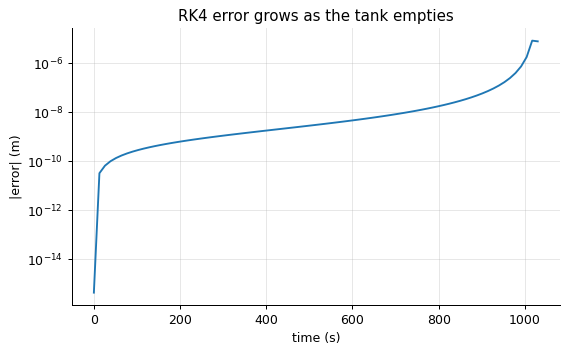

In [2]:
A_tank, a_orifice, Cd, g, h0 = 1.0, 1.0e-3, 0.62, 9.81, 2.0
t_drain = A_tank / (Cd * a_orifice) * np.sqrt(2 * h0 / g)
rhs = lambda t, h: [-Cd * a_orifice / A_tank * np.sqrt(2 * g * max(h[0], 0.0))]
h_exact = lambda t: (np.sqrt(h0) - Cd * a_orifice / A_tank * np.sqrt(g / 2) * t)**2
print(f"exact draining time {t_drain:.1f} s")
for n in (20, 80, 320):
    t, h = odes.rk4(rhs, [h0], 0, t_drain, n)
    err = np.abs(h[:, 0] - h_exact(t))
    print(f"{n:>3} steps: error at t/2 {err[n//2]:.1e} m, at the end {err[-1]:.1e} m")
t, h = odes.rk4(rhs, [h0], 0, t_drain, 80)
plt.semilogy(t, np.abs(h[:, 0] - h_exact(t)) + 1e-18); plt.xlabel("time (s)"); plt.ylabel("|error| (m)")
plt.title("RK4 error grows as the tank empties"); plt.show()

RK4 is extremely accurate for most of the draining, but the error grows sharply as $h \to 0$. There the
right-hand side $\propto \sqrt h$ has an infinite derivative, so the smoothness that RK4's error formula
assumes is lost - the same reason the turbulent profile of notebook 00 converged slowly. The error at the
end also converges much more slowly with the step size than the error at mid-time. (Near-singular
behaviour like this is where adaptive step control helps most.)

## Exercise 2

For the series reaction, find the $k_1$ that maximises $C_B$ at a fixed batch time of 3 min
   (an optimisation wrapped around an ODE solver).

optimal k1 = 1.1548 1/min; C_B(3 min) = 1.2518 mol/L (RK4 check 1.2518)


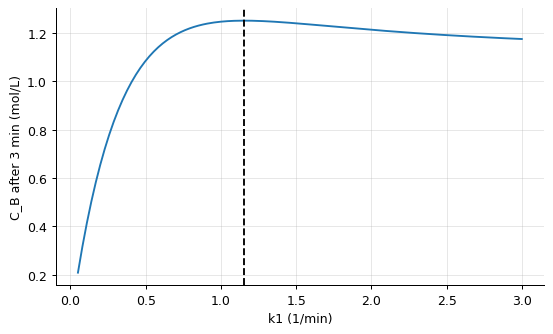

In [3]:
def CB_at_3(k1_):
    if abs(k1_ - k2) < 1e-9:                                  # limit k1 -> k2: C_B = CA0 k t e^(-k t)
        return CA0 * k2 * 3 * np.exp(-k2 * 3)
    return CA0 * k1_ / (k2 - k1_) * (np.exp(-k1_ * 3) - np.exp(-k2 * 3))
res = optimize.golden_section(lambda kk: -CB_at_3(kk), 0.01, 5.0)
k_opt = res.x[0]
_, c = odes.rk4(lambda t, y: [-k_opt*y[0], k_opt*y[0] - k2*y[1]], [CA0, 0.0], 0, 3, 300)
print(f"optimal k1 = {k_opt:.4f} 1/min; C_B(3 min) = {-res.fun:.4f} mol/L (RK4 check {c[-1, 1]:.4f})")
kk = np.linspace(0.05, 3, 200)
plt.plot(kk, [CB_at_3(v) for v in kk]); plt.axvline(k_opt, color="k", ls="--")
plt.xlabel("k1 (1/min)"); plt.ylabel("C_B after 3 min (mol/L)"); plt.show()

There is an optimum: with a small $k_1$, too little B has formed after 3 minutes; with a very large $k_1$,
B forms almost instantly and then has 3 minutes to decay. In practice $k_1$ is adjusted through the
temperature or the catalyst - this is how a reactor operating point is chosen. Wrapping an optimiser
around a model (here even an ODE solver) is a very common pattern.

## Exercise 3

Estimate the largest stable step for RK4 on the stiff system by trial. Compare with the Euler
   limit $h < 2/k_2$.

In [4]:
k2_fast = 1000.0
stiff = lambda t, c: [-k1*c[0], k1*c[0] - k2_fast*c[1]]
for h in (0.0020, 0.0025, 0.0027, 0.0028, 0.0029, 0.0030):
    with np.errstate(all="ignore"):
        _, c = odes.rk4(stiff, [CA0, 0.0], 0, 2.0, int(round(2.0/h)))
    print(f"h = {h:.4f} (k2 h = {k2_fast*h:.2f}): C_B(2) = {c[-1, 1]:.4e}  {'stable' if abs(c[-1, 1]) < 1 else 'UNSTABLE'}")
print(f"Euler limit 2/k2 = {2/k2_fast:.4f};  RK4 theory (|lambda h| < 2.785) = {2.785/k2_fast:.4f}")

h = 0.0020 (k2 h = 2.00): C_B(2) = 3.6806e-04  stable
h = 0.0025 (k2 h = 2.50): C_B(2) = 3.6806e-04  stable
h = 0.0027 (k2 h = 2.70): C_B(2) = 3.6806e-04  stable
h = 0.0028 (k2 h = 2.80): C_B(2) = -2.4679e+04  UNSTABLE
h = 0.0029 (k2 h = 2.90): C_B(2) = -5.8948e+47  UNSTABLE
h = 0.0030 (k2 h = 3.00): C_B(2) = -4.1335e+88  UNSTABLE
Euler limit 2/k2 = 0.0020;  RK4 theory (|lambda h| < 2.785) = 0.0028


RK4 stays stable up to $k_2 h \approx 2.79$, only about 40 % more than Euler's limit of 2. Higher order
buys accuracy, not stability: every explicit method has a bounded stability region, so for stiff
problems the step is limited by the fastest time scale, however smooth the solution. Implicit methods
remove that limit.

## Exercise 4

**Implement it yourself:** Heun's method predicts with an Euler step and corrects with the average of the start and end slopes. Implement it, measure its order on the series reaction, and place it between Euler and RK4.

In [5]:
def heun(fun, y0, t0, t1, n):
    t = np.linspace(t0, t1, n + 1); y = np.empty((n + 1, len(y0))); y[0] = y0
    for i in range(n):
        h = t[i+1] - t[i]
        k_start = np.array(fun(t[i], y[i]))
        y_pred = y[i] + h * k_start                       # Euler predictor
        y[i+1] = y[i] + h/2 * (k_start + np.array(fun(t[i+1], y_pred)))   # trapezoidal corrector
    return t, y

rhs = lambda t, c: [-k1*c[0], k1*c[0] - k2*c[1], k2*c[1]]
CB_exact = CA0*k1/(k2 - k1)*(np.exp(-k1*10) - np.exp(-k2*10))
ns = np.array([80, 160, 320, 640])              # fine enough to be in the asymptotic range
for name, solver in (("Euler", odes.euler), ("Heun", heun), ("RK4", odes.rk4)):
    errs = [abs(solver(rhs, [CA0, 0, 0], 0, 10, n)[1][-1, 1] - CB_exact) for n in ns]
    print(f"{name:<6}: observed order {np.polyfit(np.log(10/ns), np.log(errs), 1)[0]:.2f}")

Euler : observed order 1.01
Heun  : observed order 1.96
RK4   : observed order 4.02


Heun's method is second order: two slope evaluations per step, between Euler (one evaluation, first
order) and RK4 (four evaluations, fourth order). For smooth problems a higher order pays off quickly -
halving the step reduces Heun's error 4-fold and RK4's 16-fold.